In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import warnings
warnings.filterwarnings("ignore")

In [2]:
df=pd.read_csv("bengaluru_house_prices.csv")

In [3]:
df.shape

(13320, 9)

In [4]:
df.columns

Index(['area_type', 'availability', 'location', 'size', 'society',
       'total_sqft', 'bath', 'balcony', 'price'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  object 
 1   availability  13320 non-null  object 
 2   location      13319 non-null  object 
 3   size          13304 non-null  object 
 4   society       7818 non-null   object 
 5   total_sqft    13320 non-null  object 
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), object(6)
memory usage: 936.7+ KB


In [6]:
df['total_sqft'].unique()

array(['1056', '2600', '1440', ..., '1133 - 1384', '774', '4689'],
      dtype=object)

In [7]:
L=[]
for i in df['total_sqft']:
    s=i.split(" - ")
    if s[0].isdigit() :
        L.append(int(s[0]))
    else:
        L.append(np.nan)

In [8]:
df['total_sqft1']=L

In [9]:
df[['total_sqft','total_sqft1']]

,total_sqft,total_sqft1
0,1056,1056.0
1,2600,2600.0
2,1440,1440.0
3,1521,1521.0
4,1200,1200.0
...,...,...
13315,3453,3453.0
13316,3600,3600.0
13317,1141,1141.0
13318,4689,4689.0


In [10]:
df[['total_sqft','total_sqft1']].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   total_sqft   13320 non-null  object 
 1   total_sqft1  13182 non-null  float64
dtypes: float64(1), object(1)
memory usage: 208.3+ KB


In [11]:
df.isna().sum()

area_type          0
availability       0
location           1
size              16
society         5502
total_sqft         0
bath              73
balcony          609
price              0
total_sqft1      138
dtype: int64

In [12]:
df.isna().mean()*100

area_type        0.000000
availability     0.000000
location         0.007508
size             0.120120
society         41.306306
total_sqft       0.000000
bath             0.548048
balcony          4.572072
price            0.000000
total_sqft1      1.036036
dtype: float64

In [13]:
df.drop(columns="society",inplace=True)
df.dropna(inplace=True)

In [14]:
df.drop(columns=["availability","total_sqft"],inplace=True)

In [15]:
df.rename(columns={'total_sqft1': 'total_sqft'}, inplace=True)

In [16]:
df.isna().sum()

area_type     0
location      0
size          0
bath          0
balcony       0
price         0
total_sqft    0
dtype: int64

In [17]:
df.duplicated().sum()

684

In [19]:
df.describe()

,bath,balcony,price,total_sqft
count,12579.000000,12579.000000,12579.000000,12579.000000
mean,2.613880,1.586295,105.709331,1509.243104
std,1.225025,0.817165,131.873587,1164.083210
min,1.000000,0.000000,8.000000,5.000000
25%,2.000000,1.000000,49.000000,1100.000000
50%,2.000000,2.000000,70.000000,1258.000000
75%,3.000000,2.000000,114.500000,1636.000000
max,40.000000,3.000000,2912.000000,52272.000000


In [18]:
df.describe(include="O")

,area_type,location,size
count,12579,12579,12579
unique,4,1257,27
top,Super built-up Area,Whitefield,2 BHK
freq,8405,513,5124


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12579 entries, 0 to 13319
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   area_type   12579 non-null  object 
 1   location    12579 non-null  object 
 2   size        12579 non-null  object 
 3   bath        12579 non-null  float64
 4   balcony     12579 non-null  float64
 5   price       12579 non-null  float64
 6   total_sqft  12579 non-null  float64
dtypes: float64(4), object(3)
memory usage: 786.2+ KB


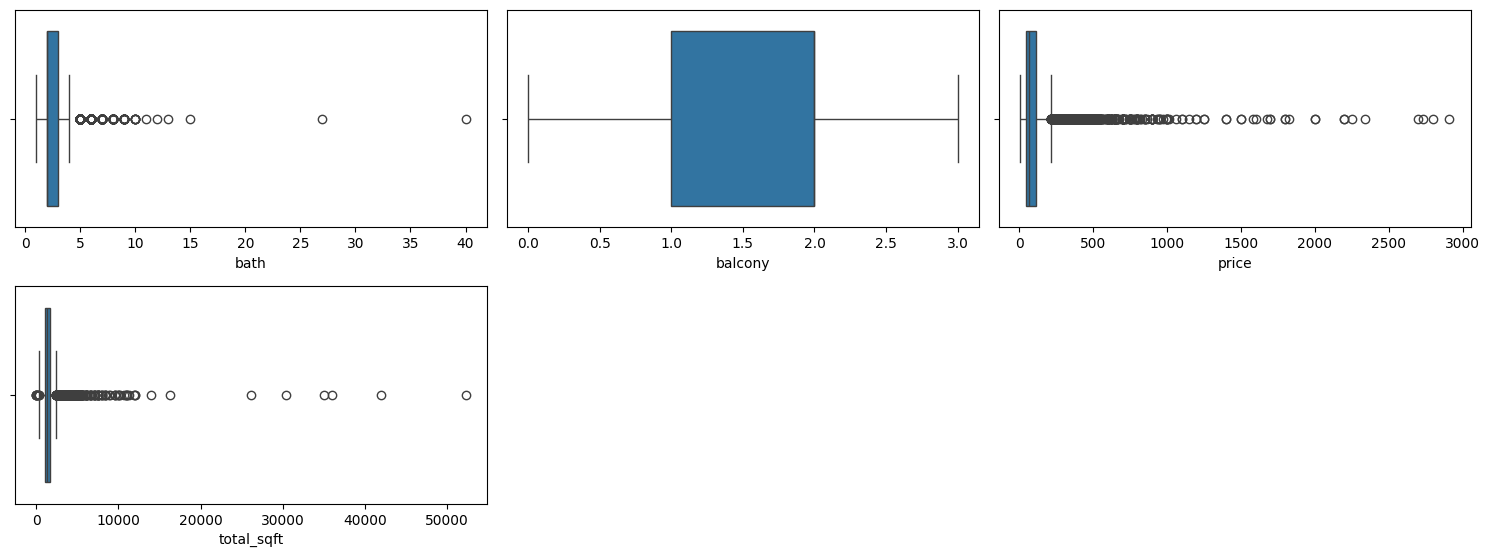

In [21]:
plt.figure(figsize=(15,8))
c=1
for i in df.describe().columns:
    plt.subplot(3,3,c)
    sns.boxplot(x=df[i])
    plt.tight_layout()
    c+=1

In [22]:
df

,area_type,location,size,bath,balcony,price,total_sqft
0,Super built-up Area,Electronic City Phase II,2 BHK,2.0,1.0,39.07,1056.0
1,Plot Area,Chikka Tirupathi,4 Bedroom,5.0,3.0,120.00,2600.0
2,Built-up Area,Uttarahalli,3 BHK,2.0,3.0,62.00,1440.0
3,Super built-up Area,Lingadheeranahalli,3 BHK,3.0,1.0,95.00,1521.0
4,Super built-up Area,Kothanur,2 BHK,2.0,1.0,51.00,1200.0
...,...,...,...,...,...,...,...
13314,Super built-up Area,Green Glen Layout,3 BHK,3.0,3.0,112.00,1715.0
13315,Built-up Area,Whitefield,5 Bedroom,4.0,0.0,231.00,3453.0
13317,Built-up Area,Raja Rajeshwari Nagar,2 BHK,2.0,1.0,60.00,1141.0
13318,Super built-up Area,Padmanabhanagar,4 BHK,4.0,1.0,488.00,4689.0


In [23]:
df2=pd.read_csv("bengaluru_house_prices.csv")

In [24]:
df2

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00
...,...,...,...,...,...,...,...,...,...
13315,Built-up Area,Ready To Move,Whitefield,5 Bedroom,ArsiaEx,3453,4.0,0.0,231.00
13316,Super built-up Area,Ready To Move,Richards Town,4 BHK,NaN,3600,5.0,NaN,400.00
13317,Built-up Area,Ready To Move,Raja Rajeshwari Nagar,2 BHK,Mahla T,1141,2.0,1.0,60.00
13318,Super built-up Area,18-Jun,Padmanabhanagar,4 BHK,SollyCl,4689,4.0,1.0,488.00
